Python Notebook for training and testing purposes

In [ ]:
!pip install -Uqq fastai
!pip install -Uqq ddgs

In [ ]:
from fastai.vision.all import *

In [ ]:
from ddgs import * #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

In [ ]:
urls = search_images('bird photos', max_images=1)
urls[0]

In [ ]:
from fastdownload import download_url
dest = 'datasets/bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

In [ ]:
download_url(search_images('forest photos', max_images=1)[0], 'forest.jpg', show_progress=False)
Image.open('forest.jpg').to_thumb(256,256)

In [4]:
searches = ('ocean', 'alps', 'river', 'lake')
path = Path('datasets')
done = False
i = 0
while not done:
    for query in searches:
        dest = (path/query)
        dest.mkdir(exist_ok=True,parents=True)
    
        import os
        count = len(os.listdir(f'datasets/{query}'))
        if count < 100:
            try:
                download_images(dest, urls=search_images(f'{query} photo'))
            except:
                i += 1
                time.sleep(0.5)

            time.sleep(5)
            resize_images(path/query, max_size=400, dest=path/query)
            done = False
        else:
            done = True

print(f'Numer of tries: {i}')

Numer of tries: 0


In [5]:
# Delete failed images ???
failed = verify_images(get_image_files(path/'river'))
failed.map(Path.unlink)
len(failed)

0

In [6]:
# Delete images in .img format
i = 0
for query in searches:
    for images in os.listdir(path/query):
        name, extension = os.path.splitext(images)
        if extension == '.img':
            photo = Path(path/query/images)
            photo.unlink()
            i += 1
        
i

3

In [ ]:
# Delete duplicate images


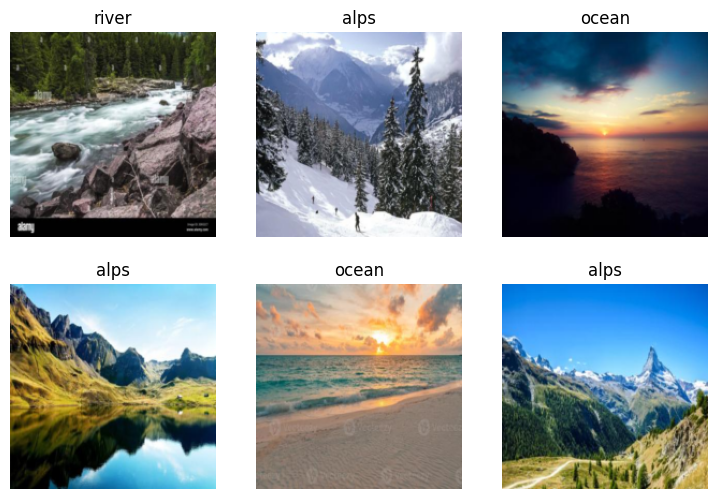

In [7]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(10)

epoch,train_loss,valid_loss,error_rate,time
0,1.888999,0.874389,0.326087,00:21


epoch,train_loss,valid_loss,error_rate,time
0,0.790734,0.617538,0.224638,00:30
1,0.526441,0.479890,0.159420,00:29
2,0.343435,0.502867,0.137681,00:28
3,0.228006,0.502023,0.130435,00:29
4,0.159788,0.466372,0.130435,00:28
5,0.117847,0.517397,0.101449,00:29
6,0.091170,0.522571,0.123188,00:29
7,0.067531,0.517371,0.123188,00:29
8,0.052148,0.502151,0.123188,00:29
9,0.042603,0.505246,0.123188,00:31


This is a: river.
Probability it's a alp: 0.0532
Probability it's a lake: 0.0075
Probability it's a ocean: 0.0424
Probability it's a river: 0.8968


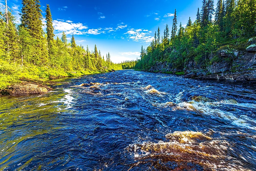

In [29]:
file = 'img.jpg', 'img1.png', 'img2.webp', 'img3.webp'
i = 3

what_is,_,probs = learn.predict(PILImage.create(file[i]))
print(f"This is a: {what_is}.")
print(f"Probability it's a alp: {probs[0]:.4f}")
print(f"Probability it's a lake: {probs[1]:.4f}")
print(f"Probability it's a ocean: {probs[2]:.4f}")
print(f"Probability it's a river: {probs[3]:.4f}")

Image.open(file[i]).to_thumb(256,256)

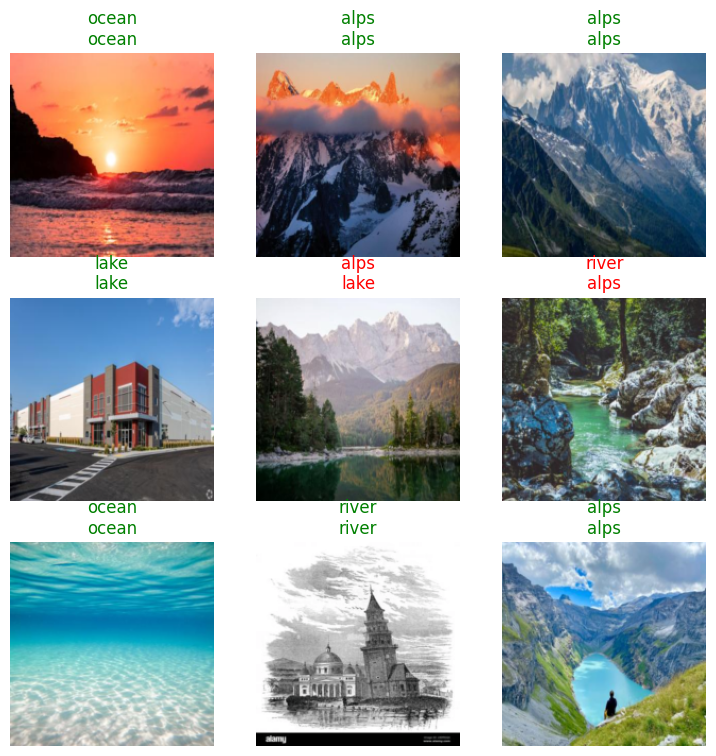

In [31]:
learn.show_results()
